# PPO on CartPole

The last rung of the policy-gradient ladder. The REINFORCE notebook showed that even with
a learned value baseline, every variant *catastrophically forgets* — a policy reaches 500
and then a single unlucky update knocks it off a cliff, because nothing bounds how far the
policy can move in one step. PPO adds that bound.

Two ideas do the work:

- **Clipped surrogate objective.** The probability ratio π_new/π_old is clipped to
  [1−ε, 1+ε], and the objective takes the *minimum* of the clipped and unclipped terms.
  This removes the incentive to push the policy past a trust region around the data-
  collecting policy — the update that causes the collapse.
- **Fixed-length rollouts.** Instead of one episode per update, collect a fixed number of
  steps spanning several episodes. This decouples the batch size from policy skill (a
  single-episode batch grows from ~20 to 500 steps as the agent improves) and gives each
  update a diverse batch rather than one correlated trajectory.

The advantage here is the Monte Carlo return minus V(s); GAE is set up (the `lam` argument
and the bootstrap value are in place) and is the natural swap for the Atari setting, where
rollouts are long and never align with episode boundaries.

In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import gymnasium as gym
import torch.nn.functional as F
from torch.optim import Adam
from torch.distributions import Categorical
import matplotlib.pyplot as plt

In [2]:
class Policy(nn.Module):

    def __init__(self,state_size, action_size, seed =0):
        super().__init__()
        torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(state_size, 32),
            nn.ReLU(),
            nn.Linear(32, action_size)
        )

    def forward(self, state):
        logits = self.net(state)
        dist = Categorical(logits=logits)

        return dist

In [3]:
class Value(nn.Module):

    def __init__(self,state_size, seed =0):
        super().__init__()
        torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(state_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, state):

        return  self.net(state)
     

In [4]:
def evaluate(policy, device,n_eps = 30, return_scores = False):
    env = gym.make("CartPole-v1")
    all_returns = []
    for _ in range(n_eps):
        state, _ = env.reset()
        ep_return = 0.0
        while True:
            state_t = torch.tensor(state).unsqueeze(0).to(device)
            dist = policy(state_t)
            action = dist.probs.argmax(dim=1).squeeze().cpu().item()
            state, reward, done, truncated, info = env.step(action)
            ep_return +=reward
            if done or truncated:
                break
        all_returns.append(ep_return)

    env.close()
    if return_scores:
        return all_returns
    return np.mean(all_returns)
                

In [5]:
env = gym.make("CartPole-v1")

In [6]:
GAMMA = 0.99
lr = .005
ppo_steps = 4
ppo_clip = .2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Collecting a rollout

`env.step()` and the reward bookkeeping are standard; the parts that matter for correctness:

- **`dones` records `terminated`, not `truncated`.** A CartPole episode truncated at the
  500-step cap is *not* a terminal state — the pole was still balanced — so its return must
  bootstrap through the cut rather than treat it as an ending. Zeroing it would teach the
  value network that surviving to 500 has no future value, which is backwards.
- **The state carries across rollouts.** `state` is passed in and returned, so consecutive
  rollouts continue the same episode stream and no transitions are wasted at boundaries.
- **`next_value` bootstraps the rollout edge.** The rollout almost always cuts an episode
  mid-flight; the value of the state after the last collected step estimates the return not
  yet observed, and seeds the backward return recursion.

The one line carrying the correctness is `R = rewards[t] + gamma * R * mask` with
`mask = 1 - done`: a true terminal (mask 0) stops the accumulation, while a truncation or a
rollout cut (mask 1) lets it bootstrap.

In [ ]:
def collect_rollout(state, policy_net, value_net, env, gamma, n_steps,lam,device):
    """Collect exactly n_steps, spanning as many episodes as needed.
    `state` carries in from the previous rollout so no transitions are wasted.
    Advantage is the Monte Carlo returns - V(s); swap in GAE later if wanted."""
    states, actions, log_probs, rewards, values, dones = [], [], [], [], [], []
    ep_returns, ep_return = [], 0.0
    with torch.no_grad():
        for _ in range(n_steps):
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            dist = policy_net(state_t)
            action = dist.sample()

            states.append(state_t.squeeze(0))
            actions.append(action.squeeze())
            log_probs.append(dist.log_prob(action).squeeze())
            values.append(value_net(state_t).squeeze())

            next_state, reward, terminated, truncated, _ = env.step(action.cpu().item())
            rewards.append(reward)
            dones.append(1.0 if terminated else 0.0)   # truncation is NOT terminal

            ep_return += reward
            state = next_state
            if terminated or truncated:
                ep_returns.append(ep_return)
                ep_return = 0.0
                state, _ = env.reset()

        # bootstrap value for the step after the rollout's last (it cut an episode short)
        last_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        next_value = value_net(last_t).squeeze()

    values = torch.stack(values)
    rewards_t = torch.tensor(rewards, dtype=torch.float32, device=device)
    dones_t = torch.tensor(dones, dtype=torch.float32, device=device)

    # returns = discounted future reward, bootstrapping past truncations and the rollout edge,
    # stopping only at true terminals
    returns = torch.zeros(n_steps, device=device)
    R = next_value
    for t in reversed(range(n_steps)):
        mask = 1.0 - dones_t[t]
        R = rewards_t[t] + gamma * R * mask
        returns[t] = R

    advantages = returns - values
    return (torch.stack(states), torch.stack(actions), torch.stack(log_probs),
            returns.detach(), advantages.detach(), state, np.mean(ep_returns))

## The PPO update

The trust-region logic lives in three lines. The ratio measures how far the current policy
has moved from the one that collected the data; the clip caps it; the `min` makes the
surrogate a pessimistic lower bound on the true objective:

```
policy_loss = -min(ratio * A, clip(ratio, 1-ε, 1+ε) * A)
```

Taking the min of the two *objectives* (not the two ratios) is what makes the clipping
behave correctly for both signs of the advantage — for A > 0 it caps how far a good action's
probability is pushed up, for A < 0 it caps how far a bad action's is pushed down, and in
both cases it leaves *unfavourable* moves unclipped so they can be corrected.

Other details: advantages are normalised per update; the loss combines policy, value
(coefficient 0.5), and an entropy bonus (0.01) that discourages premature determinism;
gradients are clipped to norm 1.0. Old log-probs and advantages are detached — gradient
flows only through the *current* policy's log-prob, which is the whole point of the ratio.

The inner loop runs `ppo_steps` epochs over the same rollout — reusing each batch several
times is what gives PPO its sample efficiency, and is only safe *because* the clip keeps the
policy from wandering too far from the data across those epochs.

In [8]:
def run(env, seed, n_steps= 2048, lam = 0.95):
    torch.manual_seed(seed)
    np.random.seed(seed)
    policy = Policy(env.observation_space.shape[0], env.action_space.n, seed).to(device)
    value_net = Value(env.observation_space.shape[0], seed).to(device)
    optimizer = Adam(list(policy.parameters()) + list(value_net.parameters()), lr=lr)

    env.reset(seed=seed)          # seed the RNG once
    env.action_space.seed(seed)
    all_rewards = []
    solved_at = None
    state, _ = env.reset()
    for n in range(400):
        states, actions, action_probs_old, returns, advantages, state, ep_reward\
                = collect_rollout(state, policy, value_net, env, GAMMA, n_steps, lam, device)
        advantages = (advantages-advantages.mean())/(advantages.std()+1e-8)

        for  _ in range(ppo_steps):
                dists = policy(states)
                values = value_net(states)
                action_probs_new = dists.log_prob(actions)
                ratios = torch.exp(action_probs_new - action_probs_old)
                clipped_ratios = torch.clamp(ratios, 1-ppo_clip, 1+ppo_clip)
                policy_loss = -torch.min(ratios*advantages, clipped_ratios*advantages).mean()
                value_loss = F.mse_loss(values,returns.unsqueeze(1))
                entropy = dists.entropy().mean()

                loss = policy_loss + 0.5 * value_loss - 0.01 * entropy

                loss.backward()
                nn.utils.clip_grad_norm_(list(policy.parameters()) + list(value_net.parameters()),1.0)
                optimizer.step()
                optimizer.zero_grad()
        
        all_rewards.append(ep_reward)
        print(f"\rEpisode {n} return: {round(ep_reward, 2)}",end="")
        if (np.mean(all_rewards[-30:])>=300) and (n%10==0) and (solved_at is None):
                eval_score = evaluate(policy, device)
                if eval_score>450 and solved_at is None:
                    solved_at = n
                    print(f'\nSolved!! Average Score for last 30 runs: {eval_score:.2f}')
    
    greedy_eval = evaluate(policy, device, return_scores=True)
    return all_rewards, solved_at, greedy_eval


In [9]:
seeds = list(range(10))
ppo_rewards = []
ppo_solved = []
ppo_greedy_evals = []
for seed in seeds:
    print(f"\nSeed: {seed}")
    all_rewards, solved_at, greedy_evals = run(env, seed)
    ppo_rewards.append(all_rewards)
    ppo_solved.append(solved_at)
    ppo_greedy_evals.append(greedy_evals)

ppo_results = {
    "scores": np.array(ppo_rewards),
    "solved_at": np.array(ppo_solved),
    "greedy_evals": np.array(ppo_greedy_evals)
}


Seed: 0
Episode 80 return: 361.81
Solved!! Average Score for last 30 runs: 500.00
Episode 399 return: 407.05
Seed: 1
Episode 60 return: 371.65
Solved!! Average Score for last 30 runs: 500.00
Episode 399 return: 426.55
Seed: 2
Episode 60 return: 336.17
Solved!! Average Score for last 30 runs: 494.60
Episode 399 return: 449.25
Seed: 3
Episode 80 return: 334.55
Solved!! Average Score for last 30 runs: 500.00
Episode 399 return: 426.55
Seed: 4
Episode 80 return: 426.55
Solved!! Average Score for last 30 runs: 499.83
Episode 399 return: 396.07
Seed: 5
Episode 60 return: 277.86
Solved!! Average Score for last 30 runs: 500.00
Episode 399 return: 447.09
Seed: 6
Episode 60 return: 390.67
Solved!! Average Score for last 30 runs: 489.30
Episode 399 return: 210.22
Seed: 7
Episode 50 return: 459.05
Solved!! Average Score for last 30 runs: 500.00
Episode 399 return: 477.51
Seed: 8
Episode 50 return: 404.25
Solved!! Average Score for last 30 runs: 500.00
Episode 399 return: 497.25
Seed: 9
Episode 60

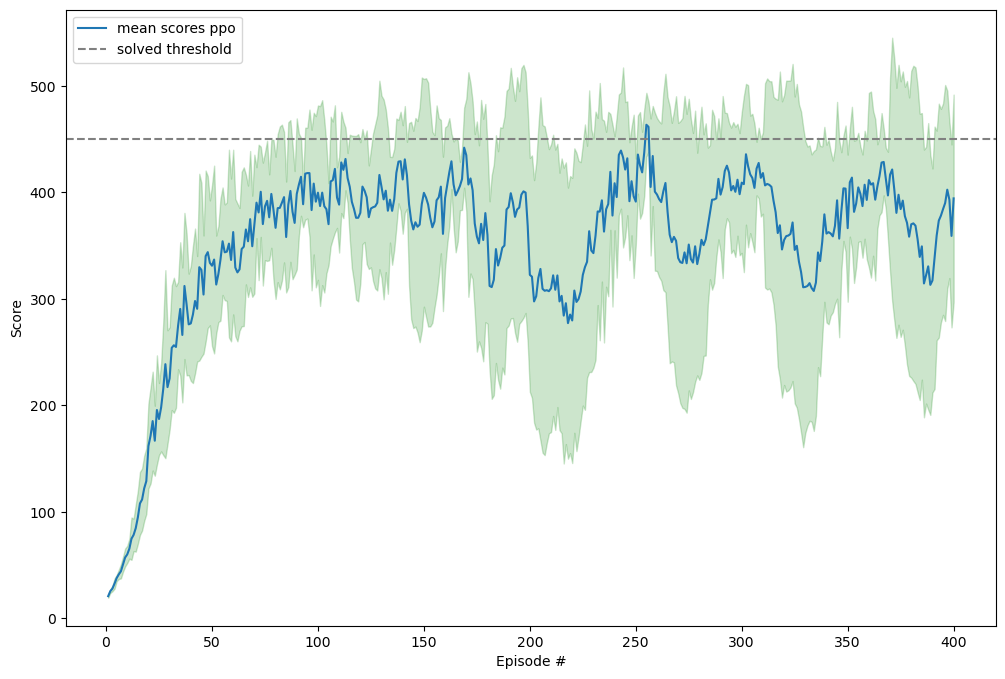

In [10]:
plt.figure(figsize=(12,8))
mean = np.nanmean(ppo_results['scores'], axis =0)
std = np.nanstd(ppo_results['scores'], axis =0)
x = np.arange(len(mean))+1
plt.plot(x,mean, label='mean scores ppo')
plt.fill_between(x,mean-std, mean+std, alpha=0.2, color='green')
plt.axhline(y=450, color='gray', linestyle='--', label='solved threshold')
plt.legend()
plt.xlabel('Episode #')
plt.ylabel('Score')
plt.show()

## Training score vs greedy score

The training score below is the mean return of the (stochastic) policy during collection.
Because the entropy bonus keeps the policy deliberately non-deterministic, this understates
the actual policy quality — the agent occasionally drops a point it would not drop if acting
greedily. The greedy evaluation further down (argmax actions) is the truer measure, and the
gap between the two is exploration noise, not a worse policy.

In [11]:
final_scores = np.nanmean(ppo_results["scores"][:, -30:], axis=1)  # last-30-episode avg per seed
solved = ppo_results["solved_at"]
print(f"PPO:")

for i,(seed, fs, s) in enumerate(zip(range(10), final_scores, solved)):
    scores_seed = ppo_results['scores'][i]
    solved_str = f"solved at episode {s}" if s is not None else "not solved"
    rolling_mean = pd.Series(scores_seed).rolling(window=100).mean().to_numpy()

    print(f"  seed={seed}: Reached {np.nanmax(rolling_mean)} then ended = {fs:.2f} | {solved_str}")
print(f"  overall mean final score: {np.mean(final_scores):.2f}\n")


PPO:
  seed=0: Reached 428.53066666666666 then ended = 439.26 | solved at episode 80
  seed=1: Reached 408.1764999999999 then ended = 438.55 | solved at episode 60
  seed=2: Reached 389.33804761904764 then ended = 419.57 | solved at episode 60
  seed=3: Reached 428.41049999999996 then ended = 432.42 | solved at episode 80
  seed=4: Reached 414.67171031746034 then ended = 365.21 | solved at episode 80
  seed=5: Reached 405.0392341269842 then ended = 156.19 | solved at episode 60
  seed=6: Reached 426.62983333333335 then ended = 210.93 | solved at episode 60
  seed=7: Reached 408.8946666666667 then ended = 368.23 | solved at episode 50
  seed=8: Reached 437.8485 then ended = 423.12 | solved at episode 50
  seed=9: Reached 428.81550000000004 then ended = 416.50 | solved at episode 60
  overall mean final score: 367.00



In [12]:
above_490=0
for i, greedy_eval in enumerate(ppo_results["greedy_evals"]):
    if np.mean(greedy_eval)>490:
        above_490+=1
    print(f"  seed={i}: greedy mean: {np.mean(greedy_eval):.2f} | std: {np.std(greedy_eval):.2f}")
print(f"\nNumber of seeds where greedy mean > 490: {above_490}")
print(f"Greedy mean: {np.mean(ppo_results['greedy_evals'])}")
print(f"Greedy min: {np.min(ppo_results['greedy_evals'])}")

  seed=0: greedy mean: 500.00 | std: 0.00
  seed=1: greedy mean: 500.00 | std: 0.00
  seed=2: greedy mean: 500.00 | std: 0.00
  seed=3: greedy mean: 500.00 | std: 0.00
  seed=4: greedy mean: 494.70 | std: 11.65
  seed=5: greedy mean: 500.00 | std: 0.00
  seed=6: greedy mean: 413.30 | std: 79.74
  seed=7: greedy mean: 500.00 | std: 0.00
  seed=8: greedy mean: 500.00 | std: 0.00
  seed=9: greedy mean: 200.87 | std: 30.72

Number of seeds where greedy mean > 490: 8
Greedy mean: 460.88666666666666
Greedy min: 166.0


## Result

Greedy evaluation (argmax actions, 30 episodes per seed) is the honest measure of policy
quality, and it separates the methods far more clearly than the stochastic training score:

- **7 of 10 seeds reach a *perfect* 500.00 with zero variance**, and an eighth (seed 4) is
  within five points of it at 494.70 ± 11.65. The training curve plateaus in the low 400s;
  that gap is entropy noise — the underlying greedy policy is flawless.
- The two genuine misses do not *collapse*: seed 9 settles into a stable sub-optimal policy
  (200.87 ± 30.72 — consistently stuck, not falling apart), and seed 6 is borderline
  (413.30 ± 79.74). Neither shows the reach-500-then-crash pattern that defined the
  REINFORCE runs.

**The single clearest illustration is seed 5.** Its *training* score ends at 156 — which
looks exactly like the catastrophic forgetting seen throughout the REINFORCE notebook. But
its *greedy* score is a perfect 500. The "collapse" was entirely exploration noise from the
entropy bonus; the policy underneath was intact the whole time. Training curves lie about a
stochastic policy in a way greedy evaluation does not.

### Why this is the point of the ladder

The REINFORCE variants lose *optimal* policies to a single bad update — a real collapse, not
a logging artefact. PPO does not. Its clipped objective bounds exactly the step that causes
that collapse, so a policy that reaches 500 stays there. Where PPO fails, it is a seed that
never escaped a local optimum during training — a different and more benign failure than a
good policy being destroyed.

On CartPole every variant lands at median 500 with a few unlucky seeds, so this is not a
benchmark PPO wins on raw score — the task is too easy to separate the methods that way. What
separates them is *stability*, and on that axis PPO does exactly what it was designed to do.

### Notes and caveats

- **Return bootstrapping at the rollout edge.** `R = next_value` (the value estimate of the
  state after the last collected step) seeds the backward recursion, so the final, unfinished
  episode of each rollout is not treated as a zero-value terminal. Setting `R = 0` instead
  biases those returns downward; it happened to score marginally higher on some seeds, but
  that is a within-noise accident of a biased target, not a real gain — and it would be
  badly wrong on Atari, where almost every rollout cuts mid-episode.
- **Advantage is Monte Carlo (returns − V), not GAE.** GAE is wired in (`lam`, the bootstrap
  value) but unused here. On CartPole it did not improve the result; it is the right
  estimator once rollouts are long and never align with episode boundaries — the Atari
  setting.
- **lr = 0.005 is high for PPO** (the usual default is ~3e-4). CartPole tolerates it with
  gradient clipping; it will not transfer to Atari.
- **One rollout per update, single environment.** Atari needs vectorised environments for
  on-policy throughput — the same rollout logic run across several envs in parallel.